In [968]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [969]:
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

In [970]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS
from model.GIFT import GIFT, SklearnGIFTWrapper, MamdaniGIFT
from model.anfis import ANFIS, SklearnAnfisWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

In [971]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0
noise_std = 0.3   # try values: 0.0, 0.05, 0.1, 0.2, 0.5  


learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [972]:
# datasetdec

from tests.uci_test import Cryotheraphy, Haberman, Heart, Glass, Segmentaition, Wine, Thyroid, Immunotherapy, Iris, BreastCancer, AdultIncome, BankMarketing, PimaDiabetes, CarEvaluation
from tests.class_test import Digits, Segmentation, Digits_UCI, Diabetes, BCW, DNA, Smoke
from torch.utils.data import DataLoader


experiment = CarEvaluation(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
#regression = experiment.target_type == 'regression'
#regression

,Description,Value
0,Session id,199
1,Target,target
2,Target type,Multiclass
3,Original data shape,"(1728, 7)"
4,Transformed data shape,"(1728, 22)"
5,Transformed train set shape,"(1384, 22)"
6,Transformed test set shape,"(344, 22)"
7,Categorical features,6
8,Preprocess,True
9,Imputation type,iterative


False

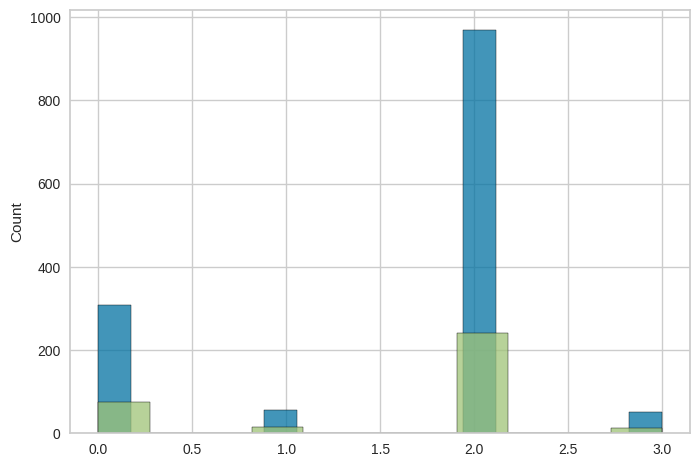

In [973]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

In [974]:
# prepare the model - modeldec

from train.early_stop import EarlyStopping

model_params = {
    'type': "gift", # anfis, unfis, gift, litanfis, gift-mamdani
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(np.unique(experiment.train_numpy()[1])),
    'rules': 2,
    'drop_out_p': 0.3,
    'binary' : binary,
    #'regression': regression,
    #'rank': 2,
    #'eta':1  
}

model_type = model_params.pop('type')

if model_type == "anfis":
    model = ANFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnAnfisWrapper(model, device=device)
elif model_type == "litanfis":
    model = LitAnfis(**model_params, dtype=torch.float32)
    sk_model = SklearnLitAnfisWrapper(model, device=device)
elif model_type == "unfis":
    model = UNFIS(**model_params, dtype=torch.float32)
elif model_type == "gift":
    model = GIFT(**model_params, dtype=torch.float32, zeta=1.0)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "gift-mamdani":
    model = MamdaniGIFT(**model_params, dtype=torch.float32, zeta=1.0)
    sk_model = SklearnGIFTWrapper(model, device=device)
else:
    raise ValueError("model_type should be one of anfis, unfis, gift")


optimizer = optim.Adam(model.parameters(), lr=lr)

steps_per_epoch=len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr,
                       steps_per_epoch=steps_per_epoch, epochs=epochs)

# Early stopping    
early_stopping = EarlyStopping(patience=10, delta=-0.00001)

alpha_decaying = np.power(min_alpha / alpha, (steps_per_epoch * epochs/2))

cos = nn.L1Loss()

if binary:
    cross = nn.BCEWithLogitsLoss()
    
    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs.squeeze(), batch_y.squeeze()) + cos(reconstructed, batch_X) * alpha 

else:
    cross = nn.CrossEntropyLoss()

    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs, batch_y.long()) + cos(reconstructed, batch_X) * alpha 

In [975]:
# train

from train.noise import add_gaussian_noise

history = []

for epoch in range(epochs):
    
    model.train()
    train_loss = 0

    if model_type == 'gift' or model_type == "litanfis":
        stats = model.get_interpretable_params()
        stats["epoch"] = epoch
        history.append(stats)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: {stats}")

    
    
    for batch_X, batch_y in train_loader:
        noisy_X = add_gaussian_noise(batch_X, noise_std) # apply the noise

        optimizer.zero_grad()
        #outputs, reconstructed, entropy = model(batch_X)
        outputs, reconstructed, entropy = model(noisy_X) # noise

        loss = criterion(batch_X, batch_y, outputs, reconstructed, alpha)
        total_loss = loss
        total_loss.backward()
        optimizer.step()
        
        # Step the scheduler, but ignore the "exceeded total steps" error
        try:
            scheduler.step()
        except ValueError as e:
            if "Tried to step" in str(e) and "total steps" in str(e):
                # Reached the end of the scheduled steps; no further adjustments needed
                pass
            else:
                raise
    
    alpha *= alpha_decaying
    train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)
        
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            output, _, _ = model(data)
            
            if binary:
                loss = cross(output.squeeze(), target.squeeze())
            else:
                loss = cross(output, target.long())

            val_loss += loss.item() * data.size(0)

    val_loss /= len(test_loader.dataset)

    print(
        f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break
    
early_stopping.load_best_model(model)

Epoch 0: {'literal_mean': 0.5023869276046753, 'literal_std': 0.023794816806912422, 'temp_mean': 0.5015488862991333, 'temp_std': 0.023165768012404442, 'weight_mean': 0.5031788349151611, 'weight_std': 0.020223019644618034, 'relax_mean': 0.5, 'relax_std': 0.0, 'literal_saturation': 0.0, 'temp_saturation': 0.0, 'weight_saturation': 0.0, 'relax_saturation': 0.0, 'epoch': 0}
Epoch 1, Train Loss: 0.0131, Val Loss: 1.3963
Epoch 2, Train Loss: 0.0082, Val Loss: 1.3699
Epoch 3, Train Loss: 0.0072, Val Loss: 1.3403
Epoch 4, Train Loss: 0.0075, Val Loss: 1.3027
Epoch 5, Train Loss: 0.0076, Val Loss: 1.2576
Epoch 6, Train Loss: 0.0076, Val Loss: 1.2001
Epoch 7, Train Loss: 0.0079, Val Loss: 1.1317
Epoch 8, Train Loss: 0.0078, Val Loss: 1.0510
Epoch 9, Train Loss: 0.0058, Val Loss: 0.9594
Epoch 10, Train Loss: 0.0053, Val Loss: 0.8591
Epoch 10: {'literal_mean': 0.5021754503250122, 'literal_std': 0.029054444283246994, 'temp_mean': 0.5000177621841431, 'temp_std': 0.04027444124221802, 'weight_mean': 0.

In [976]:
%matplotlib inline  
experiment.evaluate_model(sk_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [977]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters


from sklearn.metrics import classification_report, roc_auc_score
import pprint
import numpy as np

# Get raw labels (might be 1D or one‑hot)
y_train_raw = experiment.train_numpy()[1]
y_test_raw  = experiment.test_numpy()[1]

# Convert to 1D if necessary
if y_train_raw.ndim == 2:
    y_train = np.argmax(y_train_raw, axis=1)
    y_test  = np.argmax(y_test_raw, axis=1)
else:
    y_train = y_train_raw
    y_test  = y_test_raw

# Get predicted probabilities
y_train_proba = sk_model.predict_proba(experiment.train_numpy()[0])
y_test_proba  = sk_model.predict_proba(experiment.test_numpy()[0])

# For binary classification, roc_auc_score expects probability of the positive class
if binary:
    # If probabilities have 2 columns, take the second column (positive class)
    if y_train_proba.shape[1] == 2:
        y_train_proba_bin = y_train_proba[:, 1]
        y_test_proba_bin  = y_test_proba[:, 1]
    else:
        y_train_proba_bin = y_train_proba[:, 0]
        y_test_proba_bin  = y_test_proba[:, 0]
    train_auc = roc_auc_score(y_train, y_train_proba_bin)
    test_auc  = roc_auc_score(y_test,  y_test_proba_bin)
else:
    train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
    test_auc  = roc_auc_score(y_test,  y_test_proba, multi_class='ovr')

# Build result string
result = ""
result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(y_train, sk_model.predict(experiment.train_numpy()[0]), digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(y_test, sk_model.predict(experiment.test_numpy()[0]), digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)




Experiment Result CarEvaluation
------ train ------
              precision    recall  f1-score   support

           0     0.8787    0.9643    0.9195       308
           1     0.8636    0.6909    0.7677        55
           2     0.9927    0.9763    0.9844       969
           3     0.9184    0.8654    0.8911        52

    accuracy                         0.9581      1384
   macro avg     0.9133    0.8742    0.8907      1384
weighted avg     0.9594    0.9581    0.9578      1384
AUC	0.9971613867137905
------ test ------
              precision    recall  f1-score   support

           0     0.8152    0.9868    0.8929        76
           1     0.8571    0.4286    0.5714        14
           2     0.9957    0.9668    0.9811       241
           3     1.0000    0.8462    0.9167        13

    accuracy                         0.9448       344
   macro avg     0.9170    0.8071    0.8405       344
weighted avg     0.9504    0.9448    0.9425       344
AUC	0.9950488528701901
{'binary': Fals

In [978]:
with open(f'results/{model_type}_{experiment.__class__.__name__}_{model_params["rules"]}.txt', mode='w') as f:
    f.write(result)

In [979]:
# plot the membership functions
from model.mf_plot import plot_litanfis_mfs, plot_gift_mfs, plot_gift_param_progress
'''if model_type == "gift":
    X_train_np, y_train_np = experiment.train_numpy() 
    plot_gift_mfs(model, feature_names=None)


if model_type == 'litanfis':
    X_train_np, y_train_np = experiment.train_numpy()
    plot_litanfis_mfs(model, feature_names=None)'''


'if model_type == "gift":\n    X_train_np, y_train_np = experiment.train_numpy() \n    plot_gift_mfs(model, feature_names=None)\n\n\nif model_type == \'litanfis\':\n    X_train_np, y_train_np = experiment.train_numpy()\n    plot_litanfis_mfs(model, feature_names=None)'

In [980]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance
'''import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Determine which column(s) to use
    if y_score.shape[1] == 2:
        # Standard case: two columns, second is probability of positive class
        y_score_bin = y_score[:, 1]
    elif y_score.shape[1] == 1:
        # Single column: assume it's probability of the positive class
        y_score_bin = y_score[:, 0]
    else:
        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()'''


'import numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import roc_curve, auc, RocCurveDisplay\nfrom sklearn.preprocessing import label_binarize\n\nX_test, y_test = experiment.test_numpy()\ny_score = sk_model.predict_proba(X_test)\n\nclasses = np.unique(y_test)\nn_classes = len(classes)\n\nplt.figure(figsize=(8, 8), dpi=200)\n\n# Binary classification\nif n_classes == 2:\n    # Determine which column(s) to use\n    if y_score.shape[1] == 2:\n        # Standard case: two columns, second is probability of positive class\n        y_score_bin = y_score[:, 1]\n    elif y_score.shape[1] == 1:\n        # Single column: assume it\'s probability of the positive class\n        y_score_bin = y_score[:, 0]\n    else:\n        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")\n\n    fpr, tpr, _ = roc_curve(y_test, y_score_bin)\n    roc_auc = auc(fpr, tpr)\n\n    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,\n                    estimator_name=\'Binary classifier